In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
from PIL import Image
import PIL
import pickle

print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.4


In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [3]:
data = pd.read_csv("data_bt_dem.csv")
participantcode = data.participant.unique()

data["draws"] = data["draws"].astype(theano.config.floatX)

In [7]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}
m_dtd=data["draws"].mean()
sd_dtd=data["draws"].std()

median_dtd=data["draws"].median()


hr_bt= pm.Model(coords=coords) 

with hr_bt:
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=median_dtd, sigma=5)
    sigma_a = pm.HalfNormal("sigma_a", 5)
    mu_b = pm.Normal("mu_b", mu=0.0, sigma=10)
    sigma_b = pm.HalfNormal("sigma_b", 10)
    

    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference  
    b = pm.Normal("b", mu=mu_b, sigma=sigma_b, dims="participant")

   
    
        # Starting values for problematic parameters
    start = {
        "sigma_a": 10,    
        "sigma_b": 10
    }
    
    
    draws_est = a[participant_idx] + b[participant_idx] * data.session.values

    # Data likelihood
    draws_like = pm.Poisson(
        "draws_like", mu=draws_est, observed=data.draws, dims="obs_id")
    
    

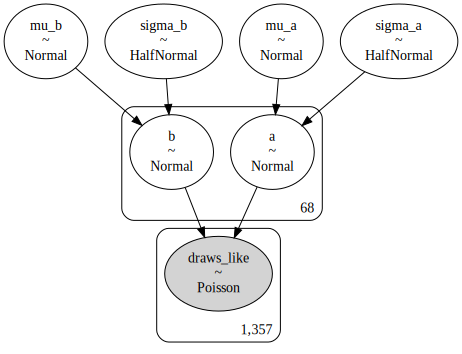

In [8]:
pm.model_to_graphviz(hr_bt)

In [9]:
with hr_bt:
    hr_bt_trace = pm.sample(10000,tune=10000, target_accept=0.9, return_inferencedata=True,
                                   start=start)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, a, sigma_b, mu_b, sigma_a, mu_a]


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 10_000 tune and 10_000 draw iterations (40_000 + 40_000 draws total) took 386 seconds.


0, dim: obs_id, 1357 =? 1357


There were 412 divergences after tuning. Increase `target_accept` or reparameterize.
There were 463 divergences after tuning. Increase `target_accept` or reparameterize.
There were 2067 divergences after tuning. Increase `target_accept` or reparameterize.
The acceptance probability does not match the target. It is 0.7535942964413276, but should be close to 0.9. Try to increase the number of tuning steps.
There were 568 divergences after tuning. Increase `target_accept` or reparameterize.
The estimated number of effective samples is smaller than 200 for some parameters.


In [ ]:
pm.model_to_graphviz(hr_bt)

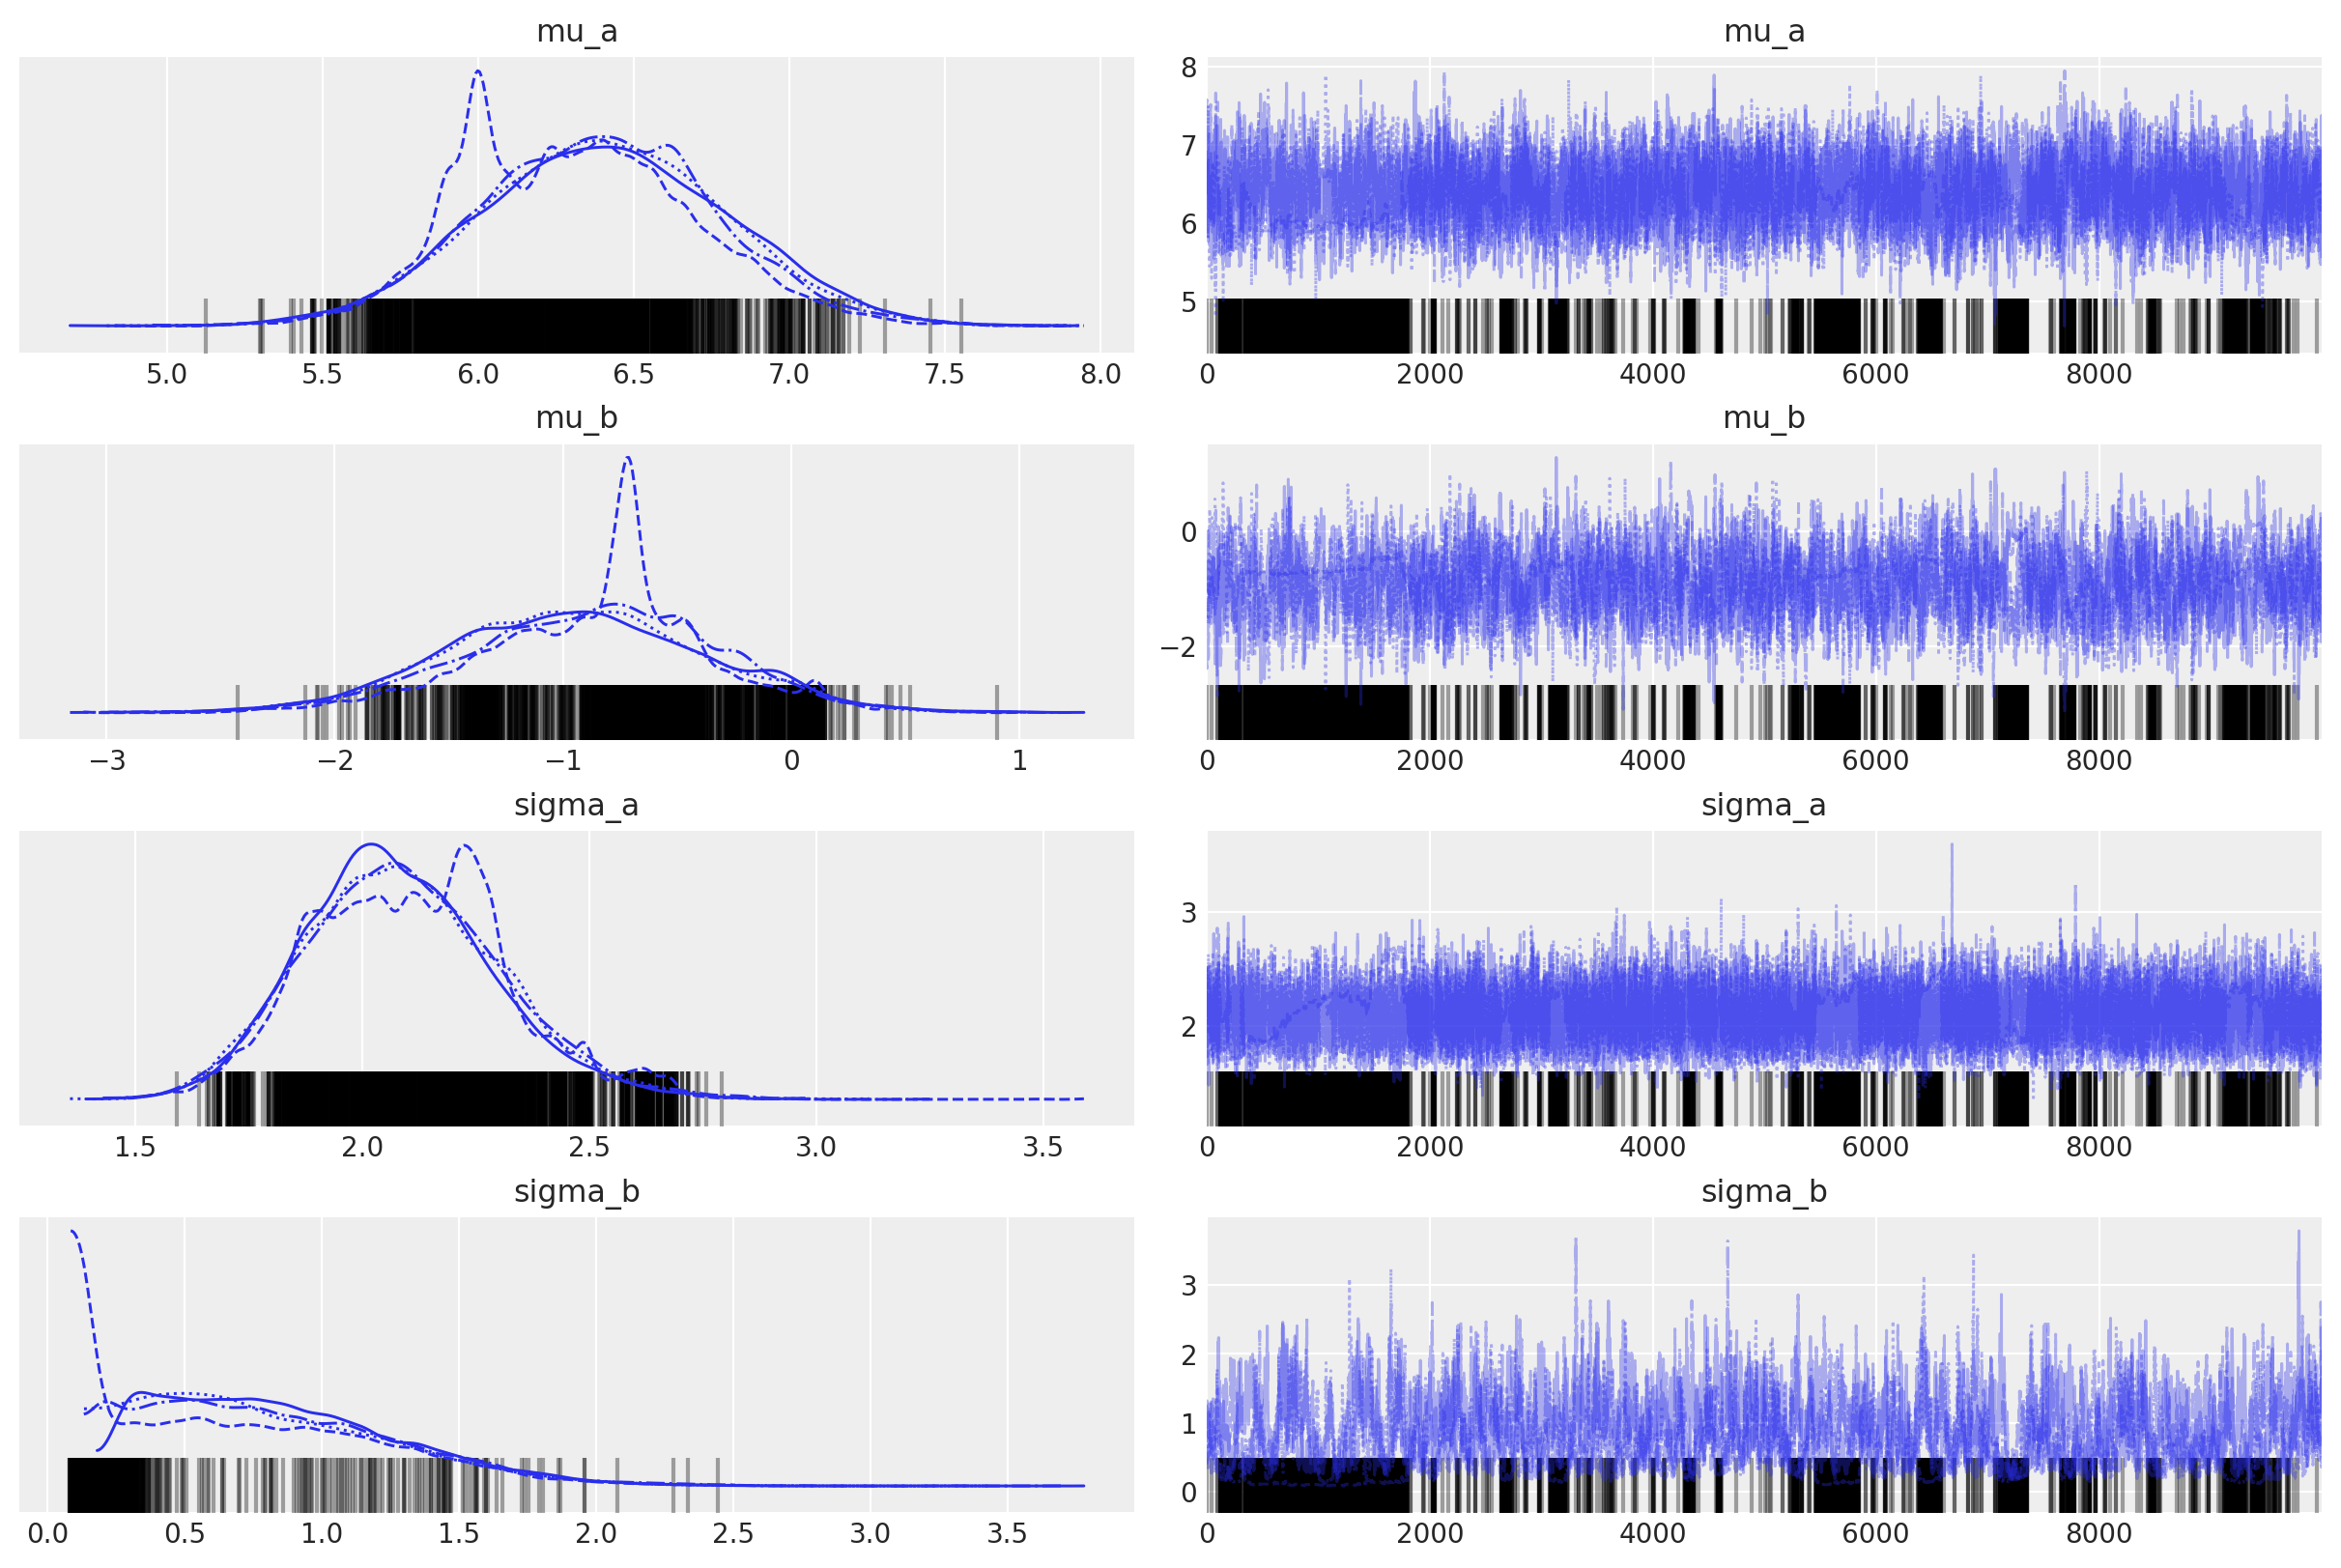

In [11]:
az.plot_trace(hr_bt_trace, var_names=["mu_a", "mu_b", "sigma_a", "sigma_b"]);


In [37]:
# Save the model
with open('hr_dtd_tms.pkl', 'wb') as file:
    pickle.dump(hr_bt, file)
    
hr_bt_trace.to_netcdf('hr_dtd_tms.nc', compress=False)

'hr_dtd_tms.nc'

In [2]:
# Load the model from the pickled file
with open('hr_dtd_tms.pkl', 'rb') as file:
    hr_bt = pickle.load(file)

hr_bt_trace = az.from_netcdf('hr_dtd_tms.nc')


In [4]:

# Calculate the log likelihood using the log_likelihood method of the InferenceData object
log_likelihood = hr_bt_trace.log_likelihood

# Compute the marginal likelihood (also known as the log pointwise predictive density)
marginal_likelihood = log_likelihood.sum()

# Optionally, you can calculate the effective number of parameters (p_waic)
p_waic = az.waic(hr_bt_trace).p_waic

# Optionally, you can calculate the Widely Applicable Information Criterion (WAIC)
waic = az.waic(hr_bt_trace,scale='deviance').waic

print("Log likelihood:", log_likelihood.draw.mean())
print("Marginal likelihood (Log pointwise predictive density):", marginal_likelihood)
print("Effective number of parameters (p_waic):", p_waic)
print("WAIC:", waic)

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Log likelihood: <xarray.DataArray 'draw' ()>
array(4999.5)
Marginal likelihood (Log pointwise predictive density): <xarray.Dataset>
Dimensions:     ()
Data variables:
    draws_like  float64 -1.097e+08
Effective number of parameters (p_waic): 31.05950419481192
WAIC: -2759.199374868474


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


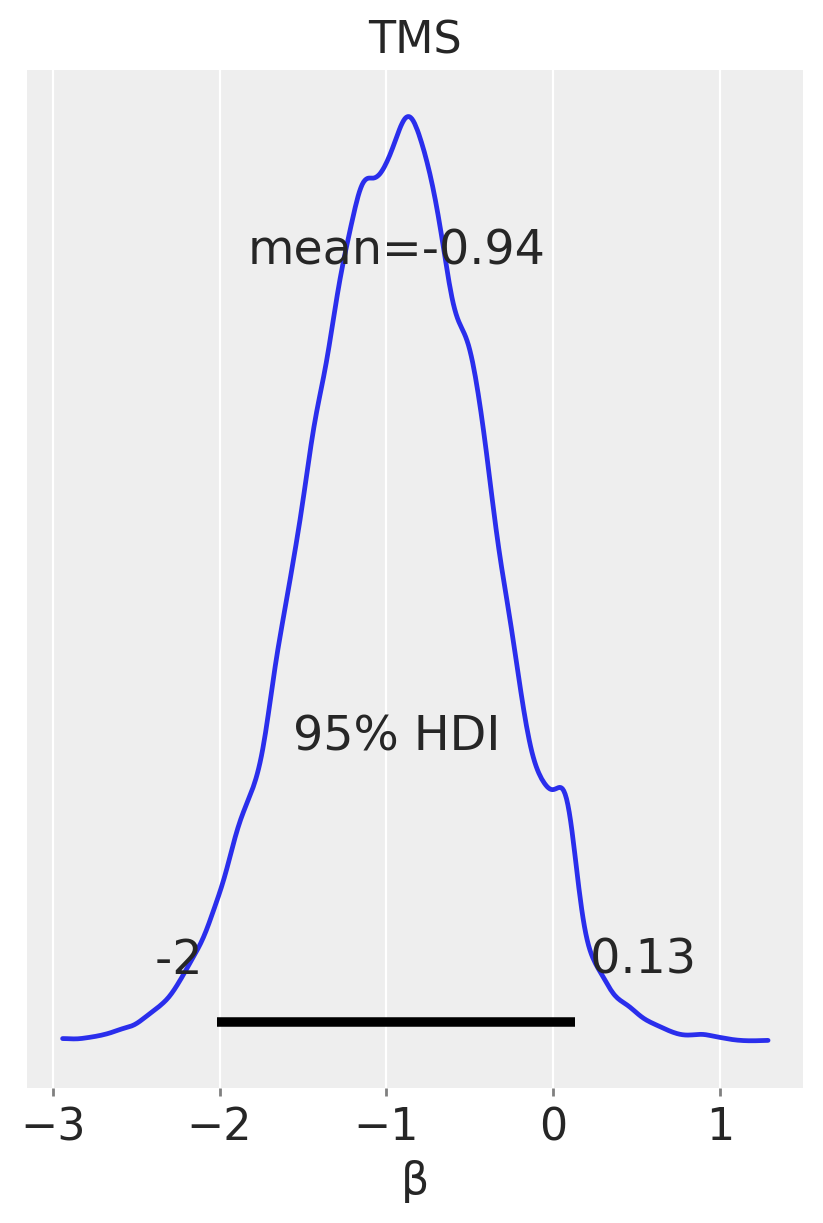

In [39]:
plot=az.plot_posterior(hr_bt_trace, var_names=["mu_b"],
                       hdi_prob=0.95,
                       textsize=16, 
                       figsize={6, 4});                     

# Set the DPI for high resolution
dpi = 300

# Get the Axes object from the plot
ax = plot  # The plot object is the Axes itself

# Set the x-axis label
ax.set_xlabel("β",fontsize=16)  # Customize the x-axis label font size as needed
ax.set_title("TMS", fontsize=16)  # Customize the title font size as needed
# Get the figure object
fig = plot.figure

# Save the image with high resolution
fig.savefig("study2_dtd_mu_b_tms_traces.png", dpi=dpi)


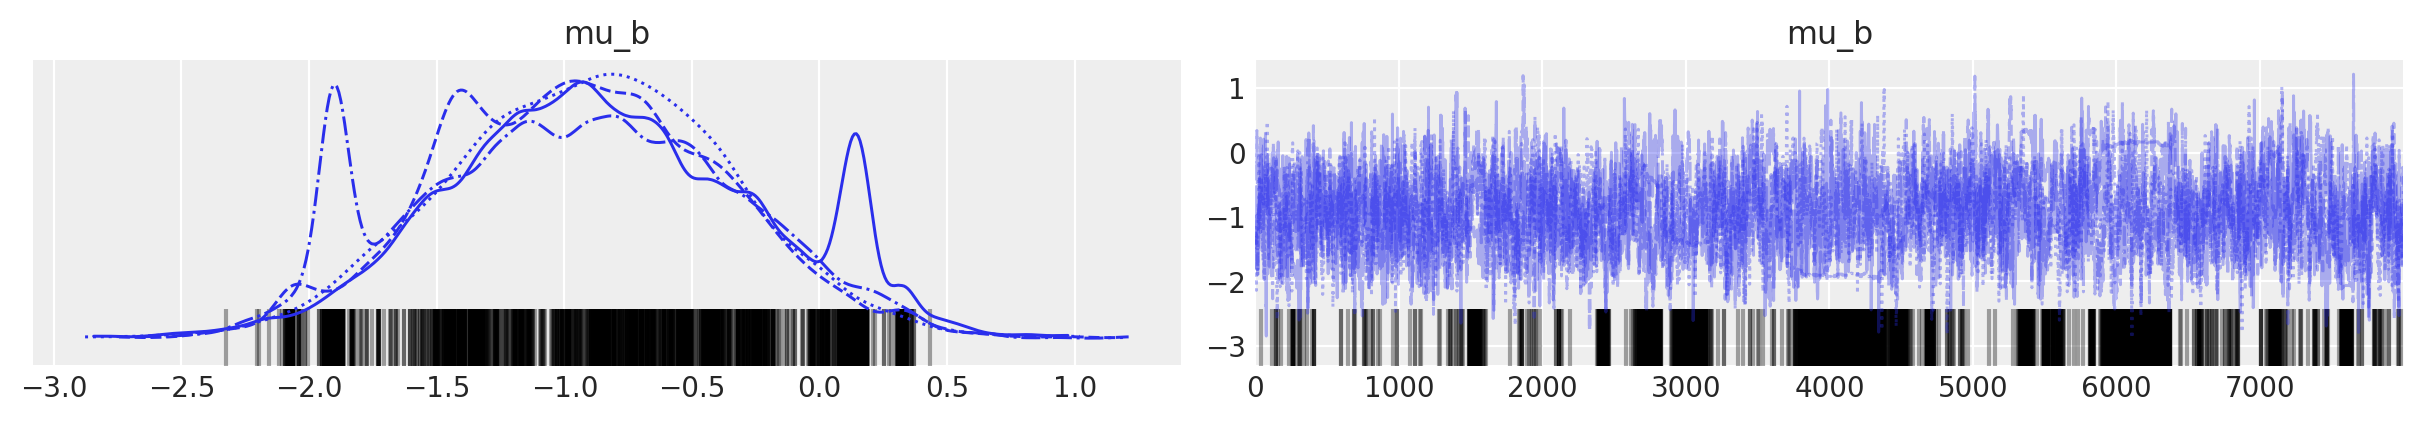

In [27]:
az.plot_trace(hr_bt_trace, var_names=["mu_b"]);


ValueError: not enough values to unpack (expected 2, got 1)

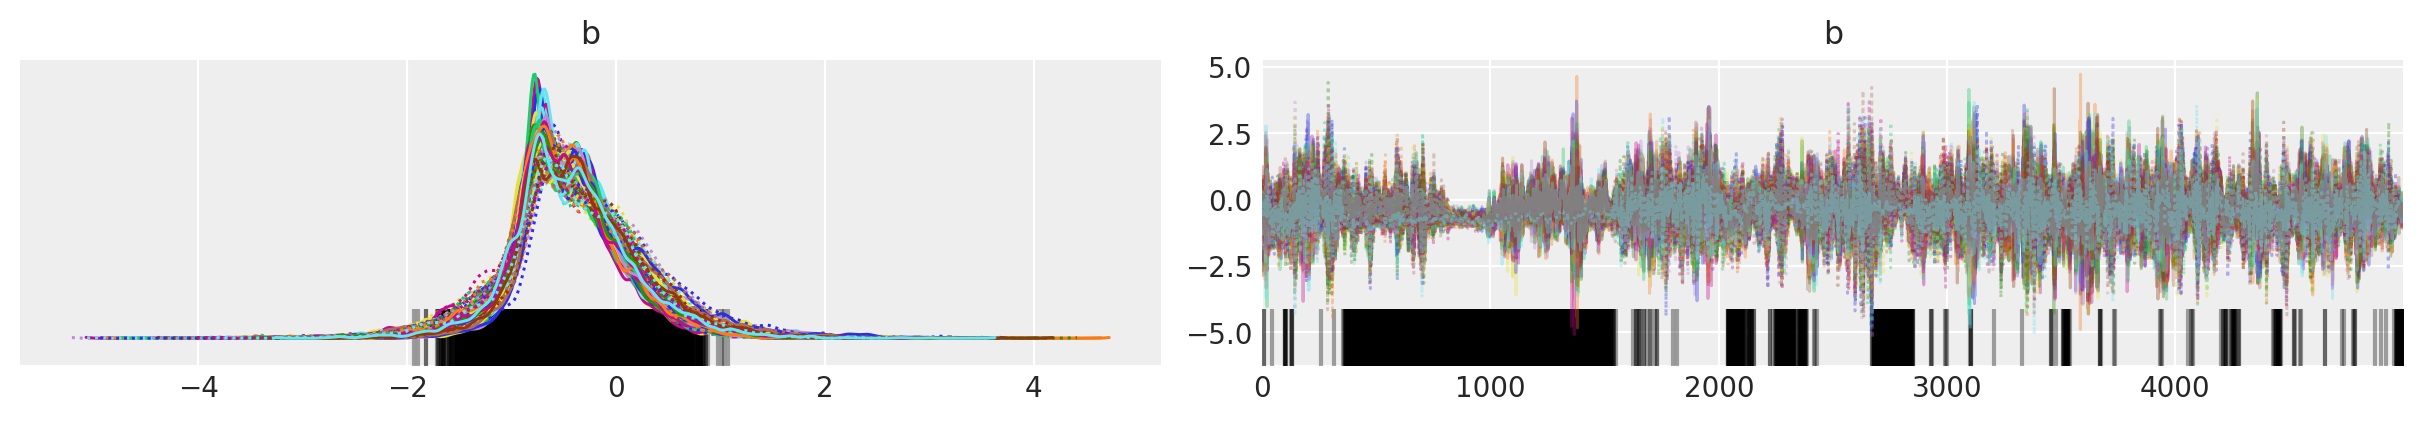

In [33]:
fig, b_trace_BT=az.plot_trace(hr_bt_trace, var_names=["b"], coords={"participant": participant});
b_trace_BT.save("b_trace_BT.jpg")

In [46]:
stat_tms_reg=pm.summary(hr_bt_trace)
stat_tms_reg

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,6.410,0.384,5.702,7.139,0.009,0.006,1987.0,6395.0,1.00
mu_b,-0.936,0.555,-1.954,0.111,0.017,0.012,1103.0,635.0,1.00
a[0],5.423,1.030,3.475,7.392,0.017,0.012,3591.0,10564.0,1.00
a[1],7.143,1.055,5.109,9.109,0.016,0.011,4342.0,11283.0,1.00
a[2],6.776,1.054,4.822,8.792,0.018,0.013,3151.0,5657.0,1.00
...,...,...,...,...,...,...,...,...,...
b[66],-0.626,0.994,-2.438,1.345,0.018,0.013,2754.0,7100.0,1.00
b[67],-0.935,1.090,-2.960,1.216,0.016,0.012,3679.0,8784.0,1.00
sigma_a,2.084,0.213,1.697,2.485,0.003,0.002,5244.0,14822.0,1.00
sigma_b,0.819,0.459,0.124,1.640,0.020,0.014,405.0,337.0,1.01


In [35]:
b_mu_reg=stat_tms_reg.loc['mu_b']['mean']
b_sigma_reg=stat_tms_reg.loc['mu_b']['sd']

In [36]:

print ("OVL Beta TMS vs O") 
b_tms=NormalDist(mu=b_mu_reg, sigma=b_sigma_reg).overlap(NormalDist(mu=0, sigma=0.05))
print (b_tms)

OVL Beta TMS vs O
0.1480741307811282


In [31]:
dtd_1=trace_groups.get_values(varname="mu", chains=1)
dtd_1=pd.DataFrame(dtd_1)

NameError: name 'trace_groups' is not defined

In [32]:
with hr_bt:
    ppc_reg = pm.sample_posterior_predictive(
        hr_bt_trace, var_names=["a", "b","draws_like"]
    )

<Axes: xlabel='draws_like'>

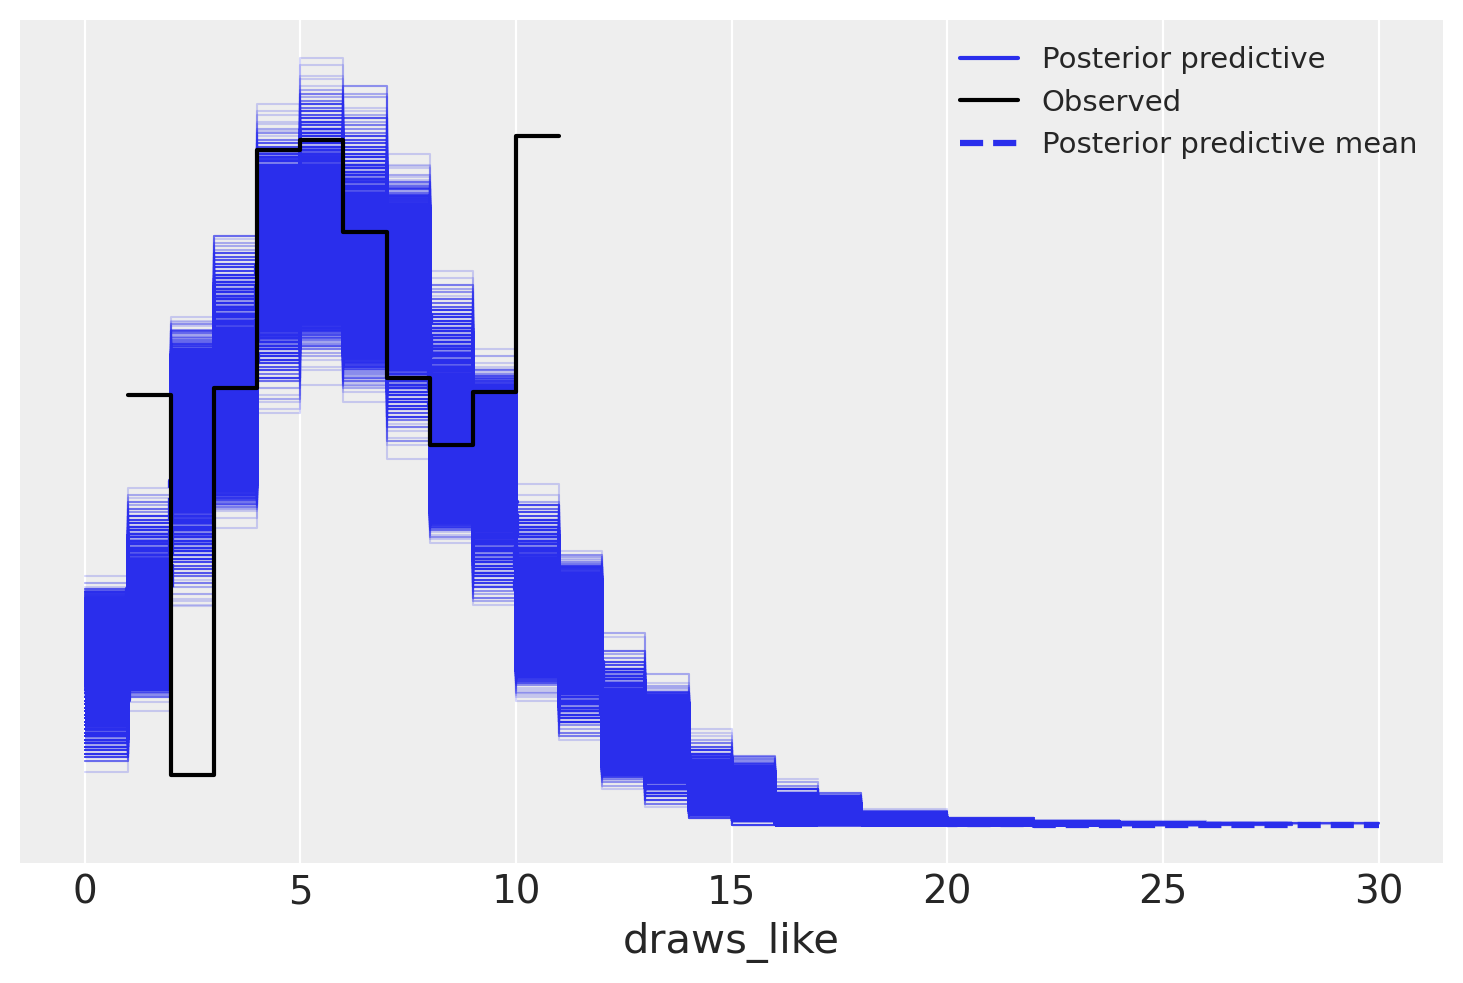

In [33]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hr_bt))

In [41]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}

median_dtd=data["draws"].median()
hr_bt_null= pm.Model(coords=coords) 

with hr_bt_null:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=median_dtd, sigma=5,testval=0.0)
    sigma_a = pm.HalfNormal("sigma_a", 5,testval=1)
    

    # Intercept for each participant, distributed around group mean mu_a
    #  here we plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect tms  
    

    # Model spec
    eps = pm.HalfCauchy("eps", 5)
        # Starting values for problematic parameters
    start = {
        "sigma_a": 10
    }    
    
    dtd_est_null = (a[participant_idx] 
                      )

    # Data likelihood
    dtd_like_null = pm.Normal(
        "dtd_like_null", mu=dtd_est_null, sigma=eps, observed=data.draws, dims="obs_id",testval=median_dtd)
    

In [42]:
with hr_bt_null:
    hr_bt_null_trace = pm.sample(10000,tune=10000, target_accept=0.9, return_inferencedata=True,
                                   start=start)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eps, a, sigma_a, mu_a]


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 10_000 tune and 10_000 draw iterations (40_000 + 40_000 draws total) took 77 seconds.


0, dim: obs_id, 1357 =? 1357


In [43]:
az.plot_trace(hr_bt_null, var_names=["mu_a", "sigma_a","eps"]);


ValueError: Can only convert xarray dataarray, xarray dataset, dict, netcdf filename, numpy array, pystan fit, pymc3 trace, emcee fit, pyro mcmc fit, numpyro mcmc fit, cmdstan fit csv filename, cmdstanpy fit to InferenceData, not Model

In [44]:
import pickle

# Save the model
with open('hr_bt_null.pkl', 'wb') as file:
    pickle.dump(hr_bt_null, file)
    
hr_bt_null_trace.to_netcdf('hr_bt_null.nc', compress=False)

'hr_bt_null.nc'

In [5]:
# Load the model from the pickled file
with open('hr_bt_null.pkl', 'rb') as file:
    hr_bt_null = pickle.load(file)

hr_bt_null_trace = az.from_netcdf('hr_bt_null_trace.nc')


In [45]:

# Calculate the log likelihood using the log_likelihood method of the InferenceData object
log_likelihood = hr_bt_null_trace.log_likelihood

# Compute the marginal likelihood (also known as the log pointwise predictive density)
marginal_likelihood = log_likelihood.sum()

# Optionally, you can calculate the effective number of parameters (p_waic)
p_waic = az.waic(hr_bt_null_trace).p_waic

# Optionally, you can calculate the Widely Applicable Information Criterion (WAIC)
waic = az.waic(hr_bt_null_trace).waic

print("Log likelihood:", log_likelihood.draw.mean())
print("Marginal likelihood (Log pointwise predictive density):", marginal_likelihood)
print("Effective number of parameters (p_waic):", p_waic)
print("WAIC:", waic)

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Log likelihood: <xarray.DataArray 'draw' ()>
array(4999.5)
Marginal likelihood (Log pointwise predictive density): <xarray.Dataset>
Dimensions:        ()
Data variables:
    dtd_like_null  float64 -1.045e+08
Effective number of parameters (p_waic): 67.00880915489367
WAIC: -2648.365901161703


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [ ]:
compare_dict = {"non centered": data1, "centered": data2}
az.compare(compare_dict)

In [8]:
pm.stats.waic(model=hr_null, trace=hr_null_trace)


TypeError: waic() got an unexpected keyword argument 'model'

In [9]:
# Assuming you have already defined and sampled your PyMC3 model (hr_conf_trace)
# Calculate the WAIC
with hr_conf:
    waic = pm.waic(hr_conf_trace)

with hr_null:
    waic_null = pm.waic(hr_null_trace)

# Get the log marginal likelihood from WAIC
marginal_likelihood_null = waic_null.waic

# Get the log marginal likelihood from WAIC
marginal_likelihood_conf = waic.waic

# Calculate the Bayes Factor using the log marginal likelihoods
BF_smc = marginal_likelihood_conf/marginal_likelihood_null

# Optionally, you can round the Bayes Factor for better readability
rounded_BF_smc = np.round(BF_smc, 2)

print(rounded_BF_smc)

NameError: name 'hr_conf' is not defined